# Eksperimen MSML - Iris Flower Dataset

**Nama Siswa:** Joshua Christian Benedict  
**Dataset:** Iris Flower Classification  
**Sumber:** Kaggle (https://www.kaggle.com/datasets/arshid/iris-flower-dataset)

# 1. Perkenalan Dataset

Dataset Iris berisi **150 record** dengan **5 atribut**:
- `SepalLengthCm` - Panjang kelopak luar bunga (cm)
- `SepalWidthCm` - Lebar kelopak luar bunga (cm)
- `PetalLengthCm` - Panjang kelopak dalam bunga (cm)
- `PetalWidthCm` - Lebar kelopak dalam bunga (cm)
- `Species` - Kelas target (Iris-setosa, Iris-versicolor, Iris-virginica)

**Tujuan:** Membangun model klasifikasi untuk memprediksi spesies bunga iris berdasarkan ukuran kelopak.

# 2. Import Library

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Library berhasil diimport.')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

Library berhasil diimport.
Pandas version: 2.2.2
NumPy version: 2.0.2


# 3. Memuat Dataset

In [9]:
# Load dataset
df = pd.read_csv('./iris_raw/iris.csv')

print('=== Info Dataset ===')
print(f'Shape: {df.shape}')
print(f'Kolom: {df.columns.tolist()}')
print()
print('=== 5 Baris Pertama ===')
df.head()

=== Info Dataset ===
Shape: (150, 5)
Kolom: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

=== 5 Baris Pertama ===


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [10]:
# Info tipe data
print('=== Info Tipe Data ===')
df.info()
print()
print('=== Statistik Deskriptif ===')
df.describe()

=== Info Tipe Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

=== Statistik Deskriptif ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [12]:
# Distribusi kelas target
print('=== Distribusi Kelas (Species) ===')
print(df['species'].value_counts())
print()
print('Persentase:')
print(df['species'].value_counts(normalize=True) * 100)

=== Distribusi Kelas (Species) ===
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Persentase:
species
Iris-setosa        33.333333
Iris-versicolor    33.333333
Iris-virginica     33.333333
Name: proportion, dtype: float64


# 4. Exploratory Data Analysis (EDA)

In [13]:
# 4.1 Cek Missing Values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

=== Missing Values ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Total missing values: 0


In [14]:
# 4.2 Cek Duplikat
print('=== Duplikat ===')
print(f'Jumlah duplikat: {df.duplicated().sum()}')

=== Duplikat ===
Jumlah duplikat: 3


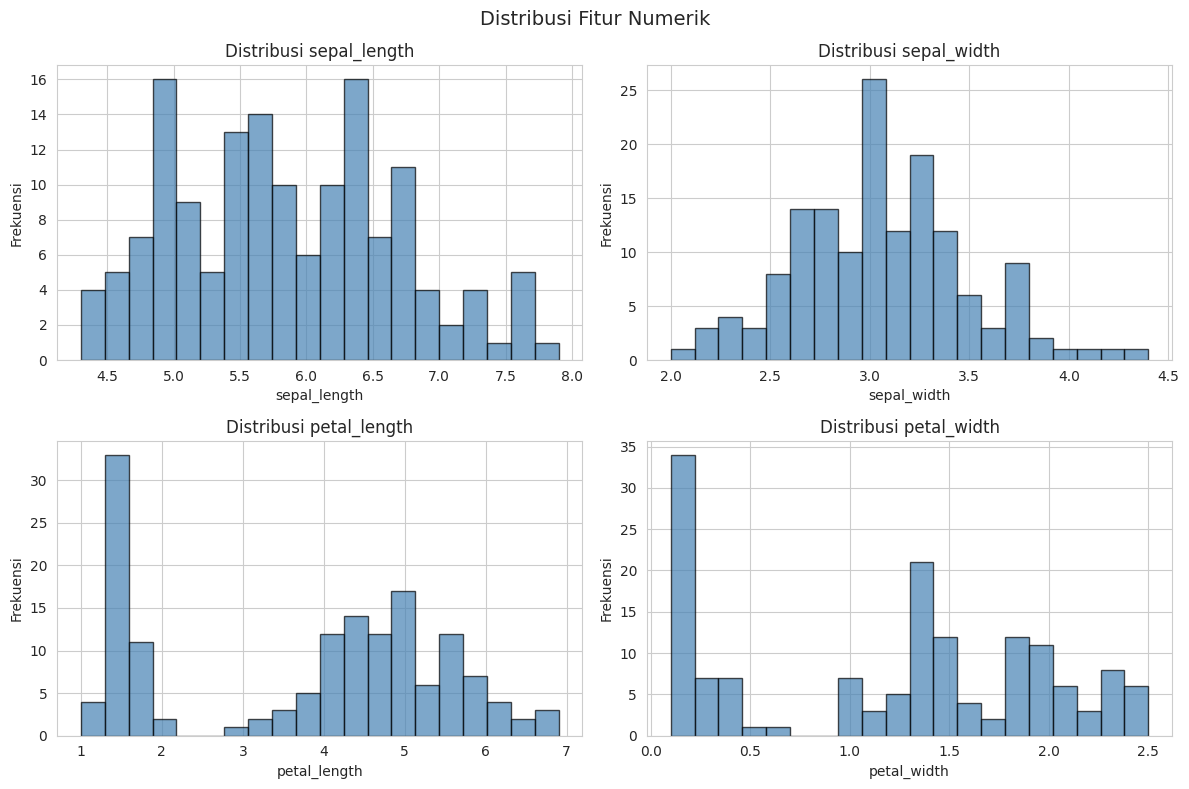

Plot distribusi fitur tersimpan.


In [16]:
# 4.3 Distribusi Setiap Fitur
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.savefig('distribusi_fitur.png', dpi=100)
plt.show()
print('Plot distribusi fitur tersimpan.')

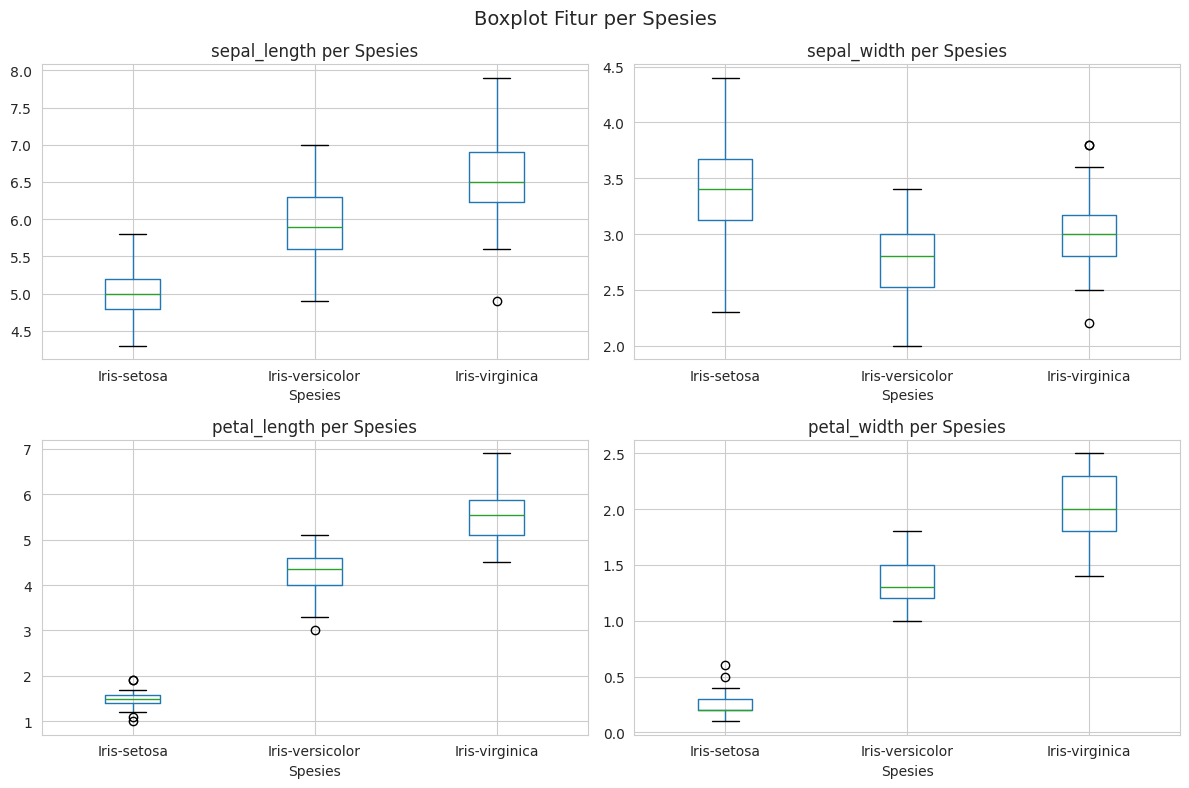

Boxplot tersimpan.


In [17]:
# 4.4 Boxplot - Distribusi per Kelas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    df.boxplot(column=col, by='species', ax=axes[i])
    axes[i].set_title(f'{col} per Spesies')
    axes[i].set_xlabel('Spesies')

plt.suptitle('Boxplot Fitur per Spesies', fontsize=14)
plt.tight_layout()
plt.savefig('boxplot_fitur.png', dpi=100)
plt.show()
print('Boxplot tersimpan.')

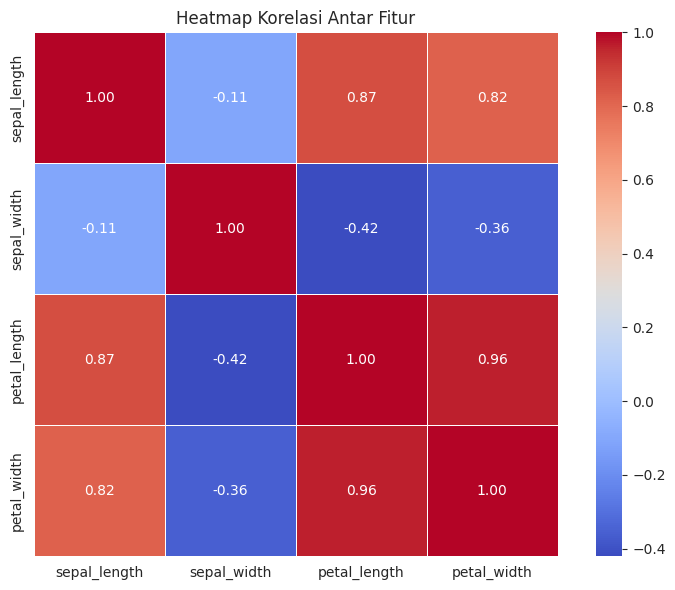

Heatmap korelasi tersimpan.

Observasi:
- PetalLengthCm dan PetalWidthCm memiliki korelasi sangat tinggi (>0.96)
- SepalLengthCm berkorelasi kuat dengan fitur petal
- SepalWidthCm memiliki korelasi lemah atau negatif dengan fitur lainnya


In [18]:
# 4.5 Heatmap Korelasi
plt.figure(figsize=(8, 6))
corr_matrix = df[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=100)
plt.show()
print('Heatmap korelasi tersimpan.')

print('\nObservasi:')
print('- PetalLengthCm dan PetalWidthCm memiliki korelasi sangat tinggi (>0.96)')
print('- SepalLengthCm berkorelasi kuat dengan fitur petal')
print('- SepalWidthCm memiliki korelasi lemah atau negatif dengan fitur lainnya')

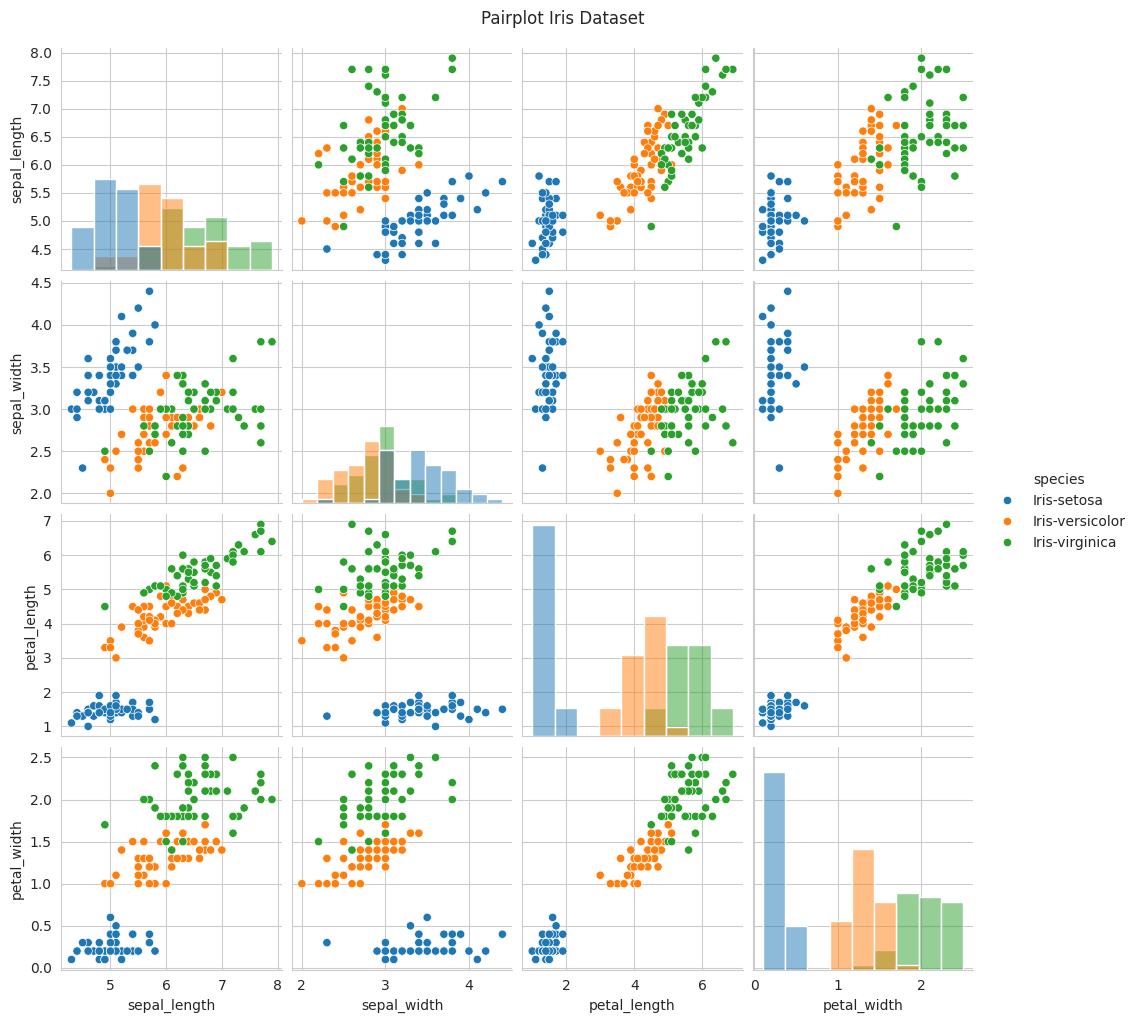

Pairplot tersimpan.


In [21]:
# 4.6 Pairplot
sns.pairplot(df[feature_cols + ['species']], hue='species', diag_kind='hist')
plt.suptitle('Pairplot Iris Dataset', y=1.02)
plt.savefig('pairplot.png', dpi=100, bbox_inches='tight')
plt.show()
print('Pairplot tersimpan.')

In [22]:
# 4.7 Deteksi Outlier menggunakan IQR
print('=== Deteksi Outlier (Metode IQR) ===')
for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'{col}: {len(outliers)} outlier(s) | Batas: [{lower_bound:.2f}, {upper_bound:.2f}]')

=== Deteksi Outlier (Metode IQR) ===
sepal_length: 0 outlier(s) | Batas: [3.15, 8.35]
sepal_width: 4 outlier(s) | Batas: [2.05, 4.05]
petal_length: 0 outlier(s) | Batas: [-3.65, 10.35]
petal_width: 0 outlier(s) | Batas: [-1.95, 4.05]


# 5. Data Preprocessing

Berdasarkan hasil EDA, tahapan preprocessing yang akan dilakukan:
1. Hapus kolom `Id` (tidak relevan untuk pemodelan)
2. Tangani missing values (drop baris dengan nilai kosong)
3. Hapus duplikat
4. Tangani outlier (clipping berdasarkan IQR)
5. Encoding kolom target `Species` menggunakan LabelEncoder
6. Standarisasi fitur numerik menggunakan StandardScaler

In [23]:
# Buat salinan dataframe
df_processed = df.copy()

# 5.1 Hapus kolom Id
if 'Id' in df_processed.columns:
    df_processed.drop(columns=['Id'], inplace=True)
    print('Kolom Id dihapus.')

print(f'Shape setelah hapus Id: {df_processed.shape}')

Shape setelah hapus Id: (150, 5)


In [24]:
# 5.2 Tangani Missing Values
before = len(df_processed)
df_processed.dropna(inplace=True)
after = len(df_processed)
print(f'Missing values: {before - after} baris dihapus. Sisa: {after} baris.')

Missing values: 0 baris dihapus. Sisa: 150 baris.


In [25]:
# 5.3 Hapus Duplikat
before = len(df_processed)
df_processed.drop_duplicates(inplace=True)
after = len(df_processed)
print(f'Duplikat: {before - after} baris dihapus. Sisa: {after} baris.')

Duplikat: 3 baris dihapus. Sisa: 147 baris.


In [27]:
# 5.4 Tangani Outlier (IQR Clipping)
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for col in feature_cols:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_processed[col] = df_processed[col].clip(lower=lower, upper=upper)

print('Outlier handling (clipping) selesai.')

Outlier handling (clipping) selesai.


In [28]:
# 5.5 Label Encoding pada kolom Species
le = LabelEncoder()
df_processed['species'] = le.fit_transform(df_processed['species'])

print('Label Encoding selesai.')
print(f'Mapping kelas: {dict(enumerate(le.classes_))}')
print(f'Distribusi target: {df_processed["species"].value_counts().to_dict()}')

Label Encoding selesai.
Mapping kelas: {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}
Distribusi target: {1: 50, 2: 49, 0: 48}


In [29]:
# 5.6 Standarisasi Fitur Numerik
scaler = StandardScaler()
df_processed[feature_cols] = scaler.fit_transform(df_processed[feature_cols])

print('Standarisasi selesai.')
print('\nStatistik setelah standarisasi:')
df_processed[feature_cols].describe().round(3)

Standarisasi selesai.

Statistik setelah standarisasi:


,sepal_length,sepal_width,petal_length,petal_width
count,147.000,147.000,147.000,147.000
mean,-0.000,0.000,-0.000,-0.000
std,1.003,1.003,1.003,1.003
min,-1.884,-2.359,-1.586,-1.468
25%,-0.916,-0.594,-1.244,-1.203
50%,-0.068,-0.123,0.354,0.121
75%,0.658,0.583,0.753,0.783
max,2.473,2.348,1.780,1.709


In [30]:
# Simpan hasil preprocessing
output_dir = 'iris_preprocessing'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'iris_preprocessing.csv')
df_processed.to_csv(output_path, index=False)

print(f'Data preprocessing tersimpan di: {output_path}')
print(f'Shape final: {df_processed.shape}')
print('\n5 baris pertama data hasil preprocessing:')
df_processed.head()

Data preprocessing tersimpan di: iris_preprocessing/iris_preprocessing.csv
Shape final: (147, 5)

5 baris pertama data hasil preprocessing:


,sepal_length,sepal_width,petal_length,petal_width,species
0,-0.915509,1.053523,-1.357737,-1.3357,0
1,-1.157560,-0.123285,-1.357737,-1.3357,0
2,-1.399610,0.347438,-1.414778,-1.3357,0
3,-1.520635,0.112077,-1.300696,-1.3357,0
4,-1.036535,1.288885,-1.357737,-1.3357,0


In [32]:
# Verifikasi split train/test
X = df_processed.drop('species', axis=1)
y = df_processed['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('=== Verifikasi Data Split ===')
print(f'Total data  : {len(df_processed)}')
print(f'Data latih  : {len(X_train)} ({len(X_train)/len(df_processed)*100:.1f}%)')
print(f'Data uji    : {len(X_test)} ({len(X_test)/len(df_processed)*100:.1f}%)')
print(f'\nDistribusi kelas train: {dict(y_train.value_counts().sort_index())}')
print(f'Distribusi kelas test : {dict(y_test.value_counts().sort_index())}')
print('\nData siap digunakan untuk pelatihan model.')

=== Verifikasi Data Split ===
Total data  : 147
Data latih  : 117 (79.6%)
Data uji    : 30 (20.4%)

Distribusi kelas train: {0: np.int64(38), 1: np.int64(40), 2: np.int64(39)}
Distribusi kelas test : {0: np.int64(10), 1: np.int64(10), 2: np.int64(10)}

Data siap digunakan untuk pelatihan model.
